# Atomic-VAEP 男女足训练数据比较：同一份女足测试集上的 atomic action-value 差异

这个 notebook 是 enriched_vaep_features_competition_events.ipynb 的 Atomic-VAEP 版本。

核心问题和 xG / xT / VAEP notebook 一样：

> 用男足数据训练出的 Atomic-VAEP 模型，和用女足数据训练出的 Atomic-VAEP 模型，当它们被用在同一份女足测试 atomic actions 上时，给出的球员价值和排名有什么差异？

整体流程：

1. 加载男女足 SPADL actions，并把进攻方向统一成从左到右。
2. 把 SPADL actions 转成 Atomic-SPADL actions。
3. 在女足比赛层面切出 held-out test games。
4. 用 socceraction 的 Atomic-VAEP feature functions 生成 action-level features 和 labels。
5. 训练两个模型：men downsampled、women。
6. 在同一批女足 test atomic actions 上预测 scoring/conceding probabilities。
7. 用 Atomic-VAEP formula 计算每个 atomic action 的 value。
8. 按球员、位置 bucket、atomic action type 分析男足模型和女足模型的差异。

## 0. Atomic-VAEP 在这里到底评价什么？

标准 VAEP 评价 SPADL action 对未来进球概率和丢球概率的影响。

Atomic-VAEP 做的是同一件事，但 action representation 更细：它先把普通 SPADL actions 拆成 Atomic-SPADL actions。例如一次传球可以拆出 pass + receival；射门后的 goal / out 等结果也会成为显式的 atomic action。

因此这里的模型学习的是：

- P(score)：当前 atomic game state 下，控球方接下来若干个 atomic actions 内进球的概率。
- P(concede)：当前 atomic game state 下，控球方接下来若干个 atomic actions 内丢球的概率。

Atomic-VAEP value 仍然是 action 前后概率变化：

- offensive value：这个 atomic action 是否提高后续进球概率。
- defensive value：这个 atomic action 是否降低后续丢球概率。
- atomic vaep value = offensive value + defensive value。

和标准 VAEP notebook 相比，下面最重要的变化是：

1. socceraction.atomic.spadl.convert_to_atomic(...) 会把 SPADL 转成 Atomic-SPADL。
2. feature / label / formula 全部改用 socceraction.atomic.vaep。
3. Atomic-SPADL 使用 x, y, dx, dy，且没有标准 SPADL 的 start_x, start_y, end_x, end_y, result_name。

## 1. Imports 和 constants

这里不在 notebook 里安装依赖。依赖应该装在项目 .venv 里。

注意：当前环境是 NumPy 2.x，而 socceraction/pandera 依赖链比较旧，所以保留一小段 NumPy compatibility aliases，作用只是让 socceraction 能正常 import，不属于 Atomic-VAEP 逻辑。

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from mplsoccer import Pitch
import numpy as np

# Compatibility aliases needed by socceraction/pandera on NumPy 2.x.
if not hasattr(np, "string_"):
    np.string_ = np.bytes_
if not hasattr(np, "float_"):
    np.float_ = np.float64
if not hasattr(np, "complex_"):
    np.complex_ = np.complex128

import pandas as pd
from scipy import stats
from sklearn.ensemble import HistGradientBoostingClassifier
import socceraction.atomic.spadl as atomic_spadl
import socceraction.atomic.vaep.features as fs
import socceraction.atomic.vaep.labels as lab
from socceraction.atomic.vaep import formula as vaep_formula

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.ChainedAssignmentError)

CACHE_DIR = Path("vaep_data")
CACHE_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
ATOMIC_DIRECTION_SUFFIX = "ltr"

PITCH_LENGTH = 105.0
PITCH_WIDTH = 68.0
SPATIAL_GRID_ROWS = 12
SPATIAL_GRID_COLS = 16
MIN_SPATIAL_GRID_ACTIONS = 20

N_PREVIOUS_ACTIONS = 3
VAEP_LABEL_HORIZON = 10  # atomic-action horizon
MIN_ACTIONS_PER_PLAYER = 100
MIN_ACTIONS_PER_ACTION_TYPE = 500
MIN_PLAYERS_PER_POSITION_BUCKET = 2

print("ready")

ready


## 2. Cache tags

这个 notebook 只读取已经生成好的 Atomic-SPADL parquet cache：

- `vaep_data/women_atomic_spadl_ltr.parquet`
- `vaep_data/men2015_atomic_spadl_ltr.parquet`
- `vaep_data/women_pos.parquet`

这样可以删掉 raw StatsBomb event → SPADL → Atomic-SPADL 的 fallback 代码，避免 notebook 里保留实际不会执行的 loader。

In [2]:
WOMEN_CACHE_TAG = "women"
MEN_CACHE_TAG = "men2015"

## 3. 加载 cached Atomic-SPADL actions

Atomic-VAEP 需要完整 atomic action sequence。这里不再保留 raw StatsBomb event loader，只使用本地 cache。

恢复策略有两层：

1. 如果 `*_atomic_spadl_ltr.parquet` 已存在，直接读取 Atomic-SPADL cache。
2. 如果 Atomic-SPADL cache 不存在，但原 VAEP notebook 生成的 `*_spadl_ltr.parquet` 存在，就用 `socceraction.atomic.spadl.convert_to_atomic(...)` 转换并写回 `*_atomic_spadl_ltr.parquet`。

也就是说，这个 notebook 不再从 StatsBomb raw events 重建数据；它只依赖已有 Atomic cache，或依赖 VAEP pipeline 已经生成好的 SPADL cache 来恢复 Atomic cache。

In [3]:
def add_atomic_names_if_needed(actions):
    """Ensure numeric Atomic-SPADL ids also have readable type/bodypart columns."""
    required_name_columns = {"type_name", "bodypart_name"}
    if required_name_columns.issubset(actions.columns):
        return actions
    return atomic_spadl.add_names(actions)


def atomic_cache_path(cache_tag):
    """Return the local Atomic-SPADL parquet path for one dataset tag."""
    return CACHE_DIR / f"{cache_tag}_atomic_spadl_{ATOMIC_DIRECTION_SUFFIX}.parquet"


def spadl_cache_path(cache_tag):
    """Return the local VAEP/SPADL parquet path for one dataset tag."""
    return CACHE_DIR / f"{cache_tag}_spadl_{ATOMIC_DIRECTION_SUFFIX}.parquet"


def rebuild_atomic_cache_from_spadl_cache(cache_tag):
    """Rebuild Atomic-SPADL cache from the SPADL cache created by the VAEP notebook."""
    spadl_cache = spadl_cache_path(cache_tag)
    atomic_cache = atomic_cache_path(cache_tag)

    if not spadl_cache.exists():
        raise FileNotFoundError(
            f"Missing both Atomic-SPADL cache ({atomic_cache}) and VAEP/SPADL cache ({spadl_cache}). "
            "Restore the Atomic cache directly, or run the VAEP notebook first to create the SPADL cache."
        )

    print(f"[rebuild] {cache_tag}: reading VAEP/SPADL cache {spadl_cache}")
    spadl_actions = pd.read_parquet(spadl_cache)
    league_by_game = (
        spadl_actions.drop_duplicates("game_id").set_index("game_id")["league"].to_dict()
        if "league" in spadl_actions.columns
        else {}
    )

    atomic_frames = []
    game_ids = spadl_actions["game_id"].drop_duplicates().tolist()
    for game_index, (game_id, game_actions) in enumerate(spadl_actions.groupby("game_id", sort=False), start=1):
        game_actions = game_actions.sort_values(["period_id", "time_seconds", "action_id"]).reset_index(drop=True)
        atomic_actions = atomic_spadl.convert_to_atomic(game_actions)
        if league_by_game:
            atomic_actions["league"] = league_by_game.get(game_id)
        atomic_frames.append(atomic_actions)

        if game_index % 50 == 0 or game_index == len(game_ids):
            print(f"    atomic converted {game_index}/{len(game_ids)} games")

    atomic_actions = add_atomic_names_if_needed(pd.concat(atomic_frames, ignore_index=True))
    atomic_actions.to_parquet(atomic_cache, index=False)
    print(f"[cache] wrote {atomic_cache}: {len(atomic_actions):,} Atomic-SPADL actions")
    return atomic_actions


def load_cached_atomic_actions(cache_tag, load_positions=False):
    """Load Atomic-SPADL actions, rebuilding them from VAEP/SPADL cache when needed."""
    atomic_cache = atomic_cache_path(cache_tag)
    if atomic_cache.exists():
        print(f"[cache] {cache_tag} Atomic-SPADL actions")
        actions = add_atomic_names_if_needed(pd.read_parquet(atomic_cache))
    else:
        actions = rebuild_atomic_cache_from_spadl_cache(cache_tag)

    if not load_positions:
        return actions, pd.DataFrame(columns=["player_id", "position_name"])

    positions_cache = CACHE_DIR / f"{cache_tag}_pos.parquet"
    if not positions_cache.exists():
        raise FileNotFoundError(
            f"Missing positions cache: {positions_cache}. Run the VAEP notebook first or restore this cache file."
        )
    positions = pd.read_parquet(positions_cache)
    return actions, positions


women_actions, women_positions = load_cached_atomic_actions(WOMEN_CACHE_TAG, load_positions=True)
men_actions, _ = load_cached_atomic_actions(MEN_CACHE_TAG)

print(f"women atomic actions: {len(women_actions):,}")
print(f"men atomic actions:   {len(men_actions):,}")
display(women_actions.head())

[cache] women Atomic-SPADL actions
[cache] men2015 Atomic-SPADL actions
women atomic actions: 2,305,950
men atomic actions:   4,694,488


,game_id,original_event_id,action_id,period_id,time_seconds,team_id,player_id,x,y,dx,dy,type_id,bodypart_id,league,type_name,bodypart_name
0,3913082,bbcfe493-36d6-41cd-91a7-1f79f5669d6d,0,1,0.0,1475,401932.0,52.058824,34.430380,-7.235294,2.410127,0,5,WSL,pass,foot_right
1,3913082,bbcfe493-36d6-41cd-91a7-1f79f5669d6d,1,1,0.5,1475,31540.0,44.823529,36.840506,0.000000,0.000000,23,0,WSL,receival,foot
2,3913082,6e142395-798a-4fa0-8167-0edb38dea15d,2,1,1.0,1475,31540.0,44.823529,36.840506,2.647059,-2.582278,21,0,WSL,dribble,foot
3,3913082,0638c31a-67b0-41d8-a8b9-e653576a4449,3,1,3.0,1475,31540.0,47.470588,34.258228,0.000000,0.000000,7,0,WSL,take_on,foot
4,3913082,dbd3f4d1-0745-4230-8788-e9e0290d9744,4,1,3.0,1475,31540.0,47.470588,34.258228,1.764706,-4.131646,21,0,WSL,dribble,foot


## 4. 共享女足 test games、位置表和门将过滤

和 xG / xT / VAEP notebook 一样，test split 在 game level 做，而不是 action level。这样同一场比赛不会同时出现在 train 和 test 里。

位置映射继续来自 cached `women_pos.parquet`。后续球员层面比较会过滤门将，因为门将动作机制和 outfield players 差异很大。

In [4]:
random_generator = np.random.default_rng(RANDOM_SEED)
women_game_ids = np.sort(women_actions["game_id"].unique())

WOMEN_TEST_GAMES = set(
    random_generator.choice(
        women_game_ids,
        size=int(len(women_game_ids) * 0.30),
        replace=False,
    )
)

women_test_game_mask = women_actions["game_id"].isin(WOMEN_TEST_GAMES)
women_train_action_count = int((~women_test_game_mask).sum())
women_test_action_count = int(women_test_game_mask.sum())


def normalize_player_id_series(player_ids):
    """Convert player ids from different loaders/caches to one nullable integer key."""
    return pd.to_numeric(player_ids, errors="coerce").astype("Int64")


women_positions = women_positions.copy()
if len(women_positions):
    women_positions["player_id_key"] = normalize_player_id_series(women_positions["player_id"])
    position_map = (
        women_positions.dropna(subset=["player_id_key"])
        .groupby("player_id_key")["position_name"]
        .agg(lambda positions: positions.value_counts().index[0])
        .to_dict()
    )
else:
    position_map = {}


def primary_position_from_key(player_id_key):
    if pd.isna(player_id_key):
        return "Unknown"
    return position_map.get(int(player_id_key), "Unknown")


def is_goalkeeper_key(player_id_key):
    return "Goalkeeper" in str(primary_position_from_key(player_id_key))


def bucket_position(position_name):
    """Map granular StatsBomb positions to broad tactical buckets."""
    position_name = str(position_name)
    if "Goalkeeper" in position_name:
        return "Goalkeeper"
    if "Center Back" in position_name:
        return "Center Back"
    if "Wing Back" in position_name or position_name in {"Left Back", "Right Back"}:
        return "Fullback / Wing Back"
    if "Defensive Midfield" in position_name:
        return "Defensive Midfield"
    if "Center Midfield" in position_name:
        return "Central Midfield"
    if "Attacking Midfield" in position_name:
        return "Attacking Midfield"
    if position_name in {"Left Midfield", "Right Midfield", "Left Wing", "Right Wing"}:
        return "Wide Midfielder / Winger"
    if "Center Forward" in position_name or position_name == "Striker":
        return "Forward"
    return "Other / Unknown"


print("women test games:", len(WOMEN_TEST_GAMES), "of", len(women_game_ids))
print("women train atomic actions:", f"{women_train_action_count:,}")
print("women test atomic actions:", f"{women_test_action_count:,}")
print("positions mapped:", len(position_map))
print("goalkeepers:", sum("Goalkeeper" in str(position) for position in position_map.values()))

women test games: 231 of 771
women train atomic actions: 1,621,350
women test atomic actions: 684,600
positions mapped: 1533
goalkeepers: 138


## 5. Atomic-VAEP features 和 labels

这里使用 socceraction.atomic.vaep 的 feature / label functions。相比标准 VAEP：

- action type 来自 Atomic-SPADL，所以会有 receival、interception、goal、out 等更细粒度类型。
- 坐标特征使用 x, y, dx, dy。
- Atomic-SPADL 没有标准 SPADL 的 result_name，因为很多结果已经变成独立 atomic actions。

原始版本在这里会为男足 469 万条 atomic actions 一次性构建完整 feature、label、metadata 和 action_rows，容易在 pandas concat 时触发 MemoryError。这个版本改成：

1. 女足仍然完整建模，因为需要 train/test split 和 test metadata。
2. 先确定女足 train set 大小。
3. 男足只在 feature/label 生成阶段按全局 action row 均匀下采样到同样大小，不再构建男足 metadata/action_rows。
4. 每个 game 的 feature frame 会先压缩 dtype，降低 notebook 内存占用。

In [5]:
VAEP_FEATURE_FUNCTIONS = [
    fs.actiontype,
    fs.actiontype_onehot,
    fs.bodypart,
    fs.bodypart_onehot,
    fs.time,
    fs.team,
    fs.time_delta,
    fs.location,
    fs.polar,
    fs.movement_polar,
    fs.direction,
    fs.goalscore,
]


def compact_feature_dtypes(features):
    """Reduce feature-memory footprint before appending frames."""
    features = features.copy()
    float_columns = features.select_dtypes(include=["float64"]).columns
    integer_columns = features.select_dtypes(include=["int64", "int32"]).columns

    if len(float_columns):
        features[float_columns] = features[float_columns].astype("float32")
    for column in integer_columns:
        features[column] = pd.to_numeric(features[column], downcast="integer")
    return features


def selected_local_indices(global_positions, row_start, row_count):
    """Return local row indices selected from a sorted array of global row positions."""
    if global_positions is None:
        return None
    left = np.searchsorted(global_positions, row_start, side="left")
    right = np.searchsorted(global_positions, row_start + row_count, side="left")
    if left == right:
        return np.array([], dtype=int)
    return global_positions[left:right] - row_start


def make_vaep_dataset(actions, label, sample_size=None, include_metadata=True, include_action_rows=True):
    """Build Atomic-VAEP features and labels, optionally sampling rows while streaming games."""
    actions = actions.reset_index(drop=True)
    if sample_size is not None:
        if sample_size > len(actions):
            raise ValueError(f"sample_size={sample_size:,} is larger than {label} actions={len(actions):,}")
        sampled_positions = np.sort(
            np.random.default_rng(RANDOM_SEED).choice(
                np.arange(len(actions)),
                size=sample_size,
                replace=False,
            )
        )
    else:
        sampled_positions = None

    feature_frames = []
    label_frames = []
    metadata_frames = []
    action_row_frames = []
    row_start = 0

    for game_id, game_actions in actions.groupby("game_id", sort=False):
        game_actions = game_actions.reset_index(drop=True)
        local_indices = selected_local_indices(sampled_positions, row_start, len(game_actions))
        row_start += len(game_actions)

        if local_indices is not None and len(local_indices) == 0:
            continue

        gamestates = fs.gamestates(game_actions, N_PREVIOUS_ACTIONS)

        game_features = pd.concat(
            [feature_function(gamestates) for feature_function in VAEP_FEATURE_FUNCTIONS],
            axis=1,
        ).fillna(0)
        game_labels = pd.concat(
            [lab.scores(game_actions, VAEP_LABEL_HORIZON), lab.concedes(game_actions, VAEP_LABEL_HORIZON)],
            axis=1,
        ).fillna(0)

        if len(game_features) != len(game_labels) or len(game_features) != len(game_actions):
            raise ValueError(
                f"Atomic-VAEP alignment mismatch in game {game_id}: "
                f"actions={len(game_actions)}, features={len(game_features)}, labels={len(game_labels)}"
            )

        if local_indices is not None:
            game_features = game_features.iloc[local_indices].reset_index(drop=True)
            game_labels = game_labels.iloc[local_indices].reset_index(drop=True)
            current_actions = game_actions.iloc[local_indices].reset_index(drop=True)
        else:
            current_actions = game_actions

        feature_frames.append(compact_feature_dtypes(game_features))
        label_frames.append(game_labels.astype(bool))

        if include_metadata:
            game_metadata = pd.DataFrame(
                {
                    "dataset": label,
                    "game_id": game_id,
                    "action_id": current_actions["action_id"].values,
                    "period_id": current_actions["period_id"].values,
                    "time_seconds": current_actions["time_seconds"].values,
                    "player_id": current_actions["player_id"].values,
                    "team_id": current_actions["team_id"].values,
                    "type_name": current_actions["type_name"].values,
                    "bodypart_name": current_actions["bodypart_name"].values,
                    "x": current_actions["x"].values,
                    "y": current_actions["y"].values,
                    "dx": current_actions["dx"].values,
                    "dy": current_actions["dy"].values,
                }
            )
            game_metadata["player_id_key"] = normalize_player_id_series(game_metadata["player_id"])
            metadata_frames.append(game_metadata)

        if include_action_rows:
            action_row_frames.append(current_actions[["game_id", "team_id", "type_name"]].copy())

    features = pd.concat(feature_frames, ignore_index=True)
    labels = pd.concat(label_frames, ignore_index=True)
    metadata = pd.concat(metadata_frames, ignore_index=True) if include_metadata else None
    action_rows = pd.concat(action_row_frames, ignore_index=True) if include_action_rows else None
    return features, labels, metadata, action_rows


print("building women Atomic-VAEP dataset...")
women_features, women_labels, women_metadata, women_action_rows = make_vaep_dataset(
    women_actions,
    "women",
)

women_test_mask = women_metadata["game_id"].isin(WOMEN_TEST_GAMES).to_numpy()
women_train_mask = ~women_test_mask
women_train_size = int(women_train_mask.sum())

print("building downsampled men Atomic-VAEP dataset...")
men_features, men_labels, _, _ = make_vaep_dataset(
    men_actions,
    "men2015",
    sample_size=women_train_size,
    include_metadata=False,
    include_action_rows=False,
)

all_feature_columns = women_features.columns.union(men_features.columns)
women_features = women_features.reindex(columns=all_feature_columns, fill_value=0)
men_features = men_features.reindex(columns=all_feature_columns, fill_value=0)

print("feature shapes:")
print("- downsampled men:", men_features.shape)
print("- women train:", women_features[women_train_mask].shape)
print("- women test:", women_features[women_test_mask].shape)
print("label positive rates:")
print("- downsampled men scores/concedes:", men_labels[["scores", "concedes"]].mean().round(4).to_dict())
print("- women scores/concedes:", women_labels[["scores", "concedes"]].mean().round(4).to_dict())

building women Atomic-VAEP dataset...
building downsampled men Atomic-VAEP dataset...
feature shapes:
- downsampled men: (1621350, 154)
- women train: (1621350, 154)
- women test: (684600, 154)
label positive rates:
- downsampled men scores/concedes: {'scores': 0.0038, 'concedes': 0.0004}
- women scores/concedes: {'scores': 0.0046, 'concedes': 0.0005}


## 6. 训练 Atomic-VAEP probability models

Atomic-VAEP 和标准 VAEP 一样，先训练两个二分类模型：

- scores model：预测接下来若干个 atomic actions 内是否进球。
- concedes model：预测接下来若干个 atomic actions 内是否丢球。

为了让男女训练集规模可比，男足数据已经在 feature/label 生成阶段随机下采样到和女足 train set 一样多的 atomic actions。

In [6]:
def train_vaep_probability_models(features, labels, model_label):
    """Train scores and concedes classifiers for Atomic-VAEP."""
    scores_model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        random_state=RANDOM_SEED,
    ).fit(features, labels["scores"])

    concedes_model = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        random_state=RANDOM_SEED,
    ).fit(features, labels["concedes"])

    print(f"trained {model_label}: rows={len(features):,}")
    return {"scores": scores_model, "concedes": concedes_model}


def predict_scores_and_concedes(models, features):
    """Predict P(scores) and P(concedes) for a feature matrix."""
    return (
        models["scores"].predict_proba(features)[:, 1],
        models["concedes"].predict_proba(features)[:, 1],
    )


women_train_features = women_features[women_train_mask].reset_index(drop=True)
women_train_labels = women_labels[women_train_mask].reset_index(drop=True)
women_test_features = women_features[women_test_mask].reset_index(drop=True)
women_test_action_rows = women_action_rows[women_test_mask].reset_index(drop=True)
women_test_metadata = women_metadata[women_test_mask].reset_index(drop=True)

men_downsampled_features = men_features.reset_index(drop=True)
men_downsampled_labels = men_labels.reset_index(drop=True)

if len(men_downsampled_features) != len(women_train_features):
    raise ValueError(
        "Downsampled men Atomic-VAEP sample does not match women train size: "
        f"men={len(men_downsampled_features):,}, women_train={len(women_train_features):,}"
    )

men_downsampled_vaep_models = train_vaep_probability_models(
    men_downsampled_features,
    men_downsampled_labels,
    "men downsampled",
)
women_vaep_models = train_vaep_probability_models(women_train_features, women_train_labels, "women train")

trained men downsampled: rows=1,621,350
trained women train: rows=1,621,350


## 7. 在同一份女足 test atomic actions 上计算 Atomic-VAEP value

这一步是核心比较：同一批女足 test atomic actions，分别用男足模型和女足模型预测 P(score) / P(concede)，再用标准 Atomic-VAEP formula 转成 action value。

Atomic-VAEP value 会用到上一条 action 的 state value，因此这里按 game 分开计算，避免一场比赛的最后一个 action 意外影响下一场比赛的第一个 action。

主比较使用 men downsampled vs women。full-size men model 暂时不跑。

In [7]:
def calculate_vaep_values_by_game(action_rows, score_probability, concede_probability):
    """Compute Atomic-VAEP values independently within each game."""
    action_rows = action_rows.reset_index(drop=True)
    probabilities = pd.DataFrame(
        {
            "game_id": action_rows["game_id"].values,
            "scores": score_probability,
            "concedes": concede_probability,
        }
    )

    value_frames = []
    for _, game_probabilities in probabilities.groupby("game_id", sort=False):
        row_indices = game_probabilities.index
        game_values = vaep_formula.value(
            action_rows.iloc[row_indices].reset_index(drop=True),
            game_probabilities["scores"].reset_index(drop=True),
            game_probabilities["concedes"].reset_index(drop=True),
        )
        game_values.index = row_indices
        value_frames.append(game_values)

    return pd.concat(value_frames).sort_index().reset_index(drop=True)


def add_model_vaep_values(scored_actions, action_rows, features, models, prefix):
    """Add P(score), P(concede), and Atomic-VAEP value for one model."""
    score_probability, concede_probability = predict_scores_and_concedes(models, features)
    vaep_values = calculate_vaep_values_by_game(action_rows, score_probability, concede_probability)

    scored_actions[f"{prefix}_p_scores"] = score_probability
    scored_actions[f"{prefix}_p_concedes"] = concede_probability
    scored_actions[f"{prefix}_offensive_value"] = vaep_values["offensive_value"].values
    scored_actions[f"{prefix}_defensive_value"] = vaep_values["defensive_value"].values
    scored_actions[f"{prefix}_vaep"] = vaep_values["vaep_value"].values
    return scored_actions


vaep_predictions = women_test_metadata.copy()
vaep_predictions = add_model_vaep_values(
    vaep_predictions,
    women_test_action_rows,
    women_test_features,
    men_downsampled_vaep_models,
    "men_downsampled",
)
vaep_predictions = add_model_vaep_values(
    vaep_predictions,
    women_test_action_rows,
    women_test_features,
    women_vaep_models,
    "women",
)

vaep_predictions["vaep_delta"] = vaep_predictions["men_downsampled_vaep"] - vaep_predictions["women_vaep"]

print("women test atomic actions scored:", f"{len(vaep_predictions):,}")
display(
    vaep_predictions[
        [
            "game_id",
            "player_id",
            "type_name",
            "bodypart_name",
            "men_downsampled_vaep",
            "women_vaep",
            "vaep_delta",
        ]
    ].head()
)

women test atomic actions scored: 684,600


,game_id,player_id,type_name,bodypart_name,men_downsampled_vaep,women_vaep,vaep_delta
0,3913167,4638.0,pass,foot_right,0.000000,0.000000,0.000000
1,3913167,46972.0,receival,foot,0.000002,-0.000010,0.000012
2,3913167,46972.0,dribble,foot,0.000006,0.000011,-0.000004
3,3913167,46972.0,pass,foot_right,0.001370,0.001353,0.000017
4,3913167,31540.0,interception,foot,0.001394,0.001283,0.000112


## 8. 球员层面汇总：男足 Atomic-VAEP vs 女足 Atomic-VAEP

按球员把 action-level Atomic-VAEP value 加总，然后比较两个模型下的球员排名。

In [8]:
def spearman_if_available(left, right, min_observations=2):
    """Return Spearman rho only when both inputs have enough non-constant values."""
    paired_values = pd.DataFrame({"left": left, "right": right}).dropna()
    if len(paired_values) < min_observations:
        return np.nan
    if paired_values["left"].nunique() < 2 or paired_values["right"].nunique() < 2:
        return np.nan
    return stats.spearmanr(paired_values["left"], paired_values["right"])[0]


def summarize_player_vaep(scored_actions):
    """Aggregate action-level Atomic-VAEP values to player-level totals."""
    player_vaep = (
        scored_actions.groupby("player_id")
        .agg(
            player_id_key=("player_id_key", "first"),
            men_downsampled_vaep=("men_downsampled_vaep", "sum"),
            women_vaep=("women_vaep", "sum"),
            action_count=("women_vaep", "size"),
        )
        .reset_index()
    )
    player_vaep["vaep_delta"] = player_vaep["men_downsampled_vaep"] - player_vaep["women_vaep"]
    player_vaep["abs_vaep_delta"] = player_vaep["vaep_delta"].abs()
    return player_vaep


player_vaep_comparison_all = summarize_player_vaep(vaep_predictions)
player_vaep_comparison = player_vaep_comparison_all[
    (player_vaep_comparison_all["action_count"] >= MIN_ACTIONS_PER_PLAYER)
    & (~player_vaep_comparison_all["player_id_key"].map(is_goalkeeper_key))
].copy()

rho_vaep = spearman_if_available(
    player_vaep_comparison["men_downsampled_vaep"],
    player_vaep_comparison["women_vaep"],
)

print(f"Atomic-VAEP | players={len(player_vaep_comparison)} | Spearman downsampled men vs women={rho_vaep:.3f}")

display(
    player_vaep_comparison.sort_values("abs_vaep_delta", ascending=False)
    .head(20)
    .round(4)
)

Atomic-VAEP | players=1061 | Spearman downsampled men vs women=0.652


,player_id,player_id_key,men_downsampled_vaep,women_vaep,action_count,vaep_delta,abs_vaep_delta
1143,321803.0,321803,-3.4588,3.8883,1615,-7.3471,7.3471
835,53958.0,53958,-0.6562,3.9305,1172,-4.5868,4.5868
454,32892.0,32892,-1.4081,2.4090,310,-3.8171,3.8171
415,32169.0,32169,-0.3384,-4.0120,370,3.6736,3.6736
754,50117.0,50117,-1.9372,1.7141,1441,-3.6514,3.6514
941,128665.0,128665,-2.0527,1.2384,1797,-3.2910,3.2910
695,49898.0,49898,-2.8611,0.3824,1593,-3.2435,3.2435
474,41955.0,41955,-1.5506,1.5478,736,-3.0984,3.0984
751,50112.0,50112,2.4514,-0.5792,1311,3.0306,3.0306
338,25729.0,25729,2.0291,-0.9313,526,2.9604,2.9604


## 9. 球员 scatter：同一批女足 test atomic actions，不同训练数据模型

如果点贴近对角线，说明男足模型和女足模型对球员总 Atomic-VAEP 排名/分数接近。偏离越大，说明同一批 atomic actions 被两个模型估值越不同。

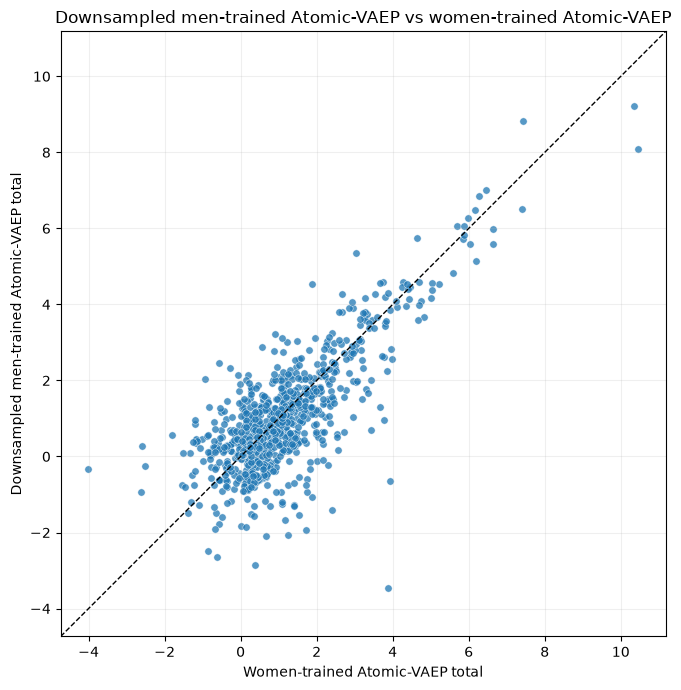

In [9]:
fig, axis = plt.subplots(figsize=(7, 7))

axis.scatter(
    player_vaep_comparison["women_vaep"],
    player_vaep_comparison["men_downsampled_vaep"],
    alpha=0.75,
    s=28,
    edgecolors="white",
    linewidths=0.4,
)
axis_min = min(player_vaep_comparison["women_vaep"].min(), player_vaep_comparison["men_downsampled_vaep"].min())
axis_max = max(player_vaep_comparison["women_vaep"].max(), player_vaep_comparison["men_downsampled_vaep"].max())
padding = (axis_max - axis_min) * 0.05 if axis_max > axis_min else 0.01
axis_min -= padding
axis_max += padding
axis.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--", color="black", linewidth=1)
axis.set_xlim(axis_min, axis_max)
axis.set_ylim(axis_min, axis_max)
axis.set_aspect("equal", adjustable="box")
axis.set_xlabel("Women-trained Atomic-VAEP total")
axis.set_ylabel("Downsampled men-trained Atomic-VAEP total")
axis.set_title("Downsampled men-trained Atomic-VAEP vs women-trained Atomic-VAEP")
axis.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 10. 按 position bucket 分析 Atomic-VAEP 排名差异

这里把 test-set 球员按主要位置分组，看男足模型和女足模型在不同位置上的排名差异是否不同。

In [10]:
player_vaep_by_position = player_vaep_comparison.copy()
player_vaep_by_position["primary_position"] = player_vaep_by_position["player_id_key"].map(primary_position_from_key)
player_vaep_by_position["position_bucket"] = player_vaep_by_position["primary_position"].map(bucket_position)

player_vaep_by_position["bucket_men_rank"] = player_vaep_by_position.groupby("position_bucket")[
    "men_downsampled_vaep"
].rank(ascending=False, method="min")
player_vaep_by_position["bucket_women_rank"] = player_vaep_by_position.groupby("position_bucket")[
    "women_vaep"
].rank(ascending=False, method="min")
player_vaep_by_position["bucket_rank_delta"] = (
    player_vaep_by_position["bucket_men_rank"] - player_vaep_by_position["bucket_women_rank"]
)
player_vaep_by_position["abs_bucket_rank_delta"] = player_vaep_by_position["bucket_rank_delta"].abs()

position_rows = []
for position_bucket, bucket_players in player_vaep_by_position.groupby("position_bucket"):
    spearman = spearman_if_available(
        bucket_players["men_downsampled_vaep"],
        bucket_players["women_vaep"],
        min_observations=MIN_PLAYERS_PER_POSITION_BUCKET,
    )

    position_rows.append(
        {
            "position_bucket": position_bucket,
            "players": len(bucket_players),
            "actions": int(bucket_players["action_count"].sum()),
            "spearman_men_vs_women_vaep": spearman,
            "aggregate_vaep_delta": bucket_players["vaep_delta"].sum(),
            "mean_vaep_delta": bucket_players["vaep_delta"].mean(),
            "mean_abs_vaep_delta": bucket_players["abs_vaep_delta"].mean(),
            "mean_bucket_rank_delta": bucket_players["bucket_rank_delta"].mean(),
            "median_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].median(),
            "max_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].max(),
        }
    )

position_bucket_vaep_summary = (
    pd.DataFrame(position_rows)
    .sort_values(["players", "actions"], ascending=False)
    .reset_index(drop=True)
)

print("Position-bucket Atomic-VAEP summary:")
display(position_bucket_vaep_summary.round(4))

print()
print("Players with largest within-bucket Atomic-VAEP rank changes:")
display(
    player_vaep_by_position.sort_values("abs_bucket_rank_delta", ascending=False)[
        [
            "player_id",
            "primary_position",
            "position_bucket",
            "action_count",
            "men_downsampled_vaep",
            "women_vaep",
            "vaep_delta",
            "bucket_men_rank",
            "bucket_women_rank",
            "bucket_rank_delta",
        ]
    ]
    .head(25)
    .round(4)
)

Position-bucket Atomic-VAEP summary:


,position_bucket,players,actions,spearman_men_vs_women_vaep,aggregate_vaep_delta,mean_vaep_delta,mean_abs_vaep_delta,mean_bucket_rank_delta,median_abs_bucket_rank_delta,max_abs_bucket_rank_delta
0,Fullback / Wing Back,224,145373,0.4133,-34.3613,-0.1534,0.6555,0.0,30.0,222.0
1,Center Back,211,169121,0.3649,-31.2984,-0.1483,0.6670,0.0,31.0,193.0
2,Defensive Midfield,169,105473,0.6447,4.8272,0.0286,0.5510,0.0,18.0,131.0
3,Wide Midfielder / Winger,164,72891,0.7047,-12.2817,-0.0749,0.6202,0.0,10.0,134.0
4,Forward,147,59155,0.8768,-8.3911,-0.0571,0.5317,0.0,9.0,74.0
5,Central Midfield,83,47845,0.6222,-3.6974,-0.0445,0.5969,0.0,8.0,70.0
6,Attacking Midfield,63,33931,0.7959,-8.2444,-0.1309,0.5354,0.0,7.0,40.0



Players with largest within-bucket Atomic-VAEP rank changes:


,player_id,primary_position,position_bucket,action_count,men_downsampled_vaep,women_vaep,vaep_delta,bucket_men_rank,bucket_women_rank,bucket_rank_delta
1143,321803.0,Left Back,Fullback / Wing Back,1615,-3.4588,3.8883,-7.3471,224.0,2.0,222.0
835,53958.0,Left Back,Fullback / Wing Back,1172,-0.6562,3.9305,-4.5868,205.0,1.0,204.0
754,50117.0,Right Back,Fullback / Wing Back,1441,-1.9372,1.7141,-3.6514,221.0,23.0,198.0
751,50112.0,Right Center Back,Center Back,1311,2.4514,-0.5792,3.0306,7.0,200.0,-193.0
686,49836.0,Left Back,Fullback / Wing Back,953,-0.9421,1.7475,-2.6896,213.0,21.0,192.0
474,41955.0,Right Center Back,Center Back,736,-1.5506,1.5478,-3.0984,207.0,18.0,189.0
659,47116.0,Right Center Back,Center Back,731,-1.0647,1.8806,-2.9452,202.0,14.0,188.0
743,50100.0,Left Back,Fullback / Wing Back,1252,-1.2880,1.4140,-2.7020,218.0,33.0,185.0
1280,408653.0,Right Wing Back,Fullback / Wing Back,528,1.2938,-0.8392,2.1330,31.0,213.0,-182.0
924,119103.0,Right Center Back,Center Back,600,-1.2936,1.4064,-2.7000,204.0,23.0,181.0


## 10.1 Position-bucket visualization

这些图分别看：

- 每个位置 bucket 内，男足 Atomic-VAEP 和女足 Atomic-VAEP 的排名相关性。
- 每个位置 bucket 内，player-level Atomic-VAEP delta 的分布，而不是只看平均值。
- 每个位置 bucket 内，男足 Atomic-VAEP 排名相对女足 Atomic-VAEP 排名的移动分布。

右图的横轴是 `player_vaep_delta = men_downsampled_vaep - women_vaep`。每一行是一类位置的球员分布；偏蓝表示该位置 bucket 的 mean delta 更负，偏红表示 mean delta 更正。黑点标出该位置 bucket 的 mean delta。

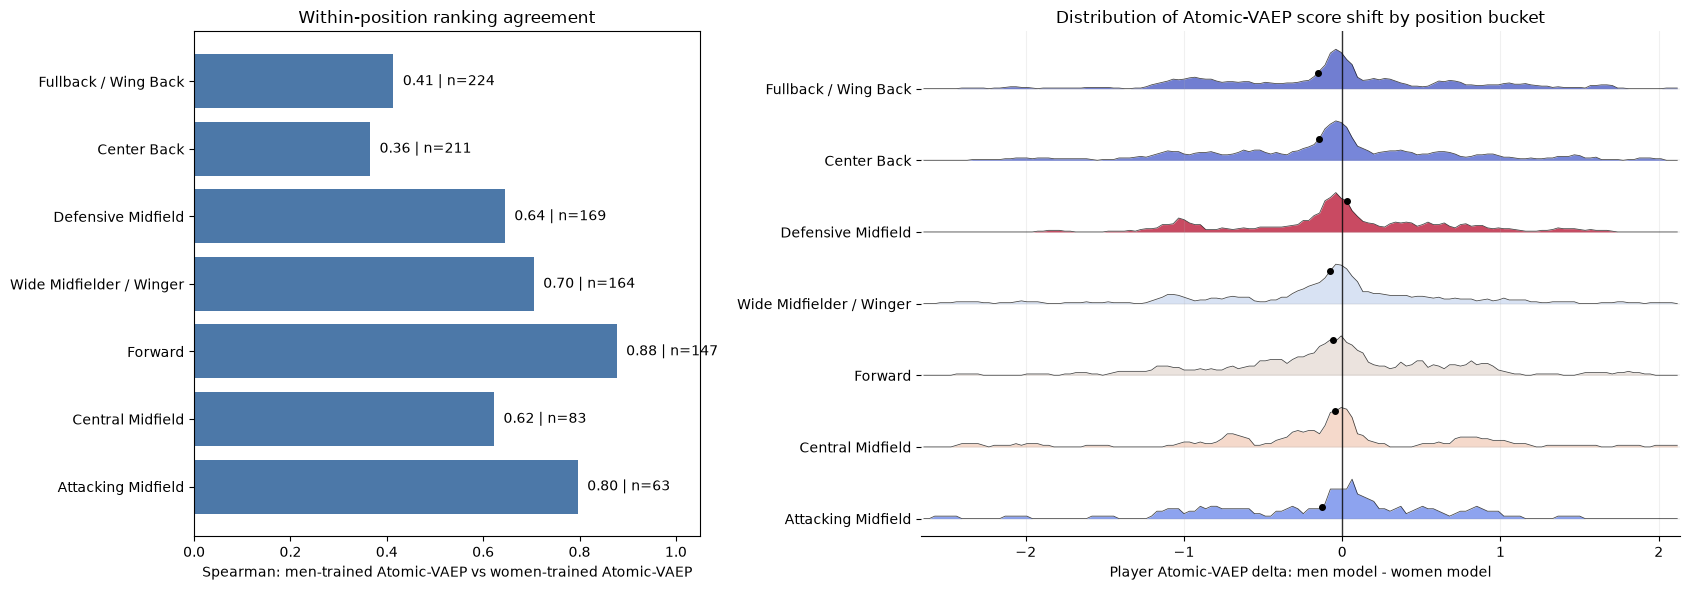

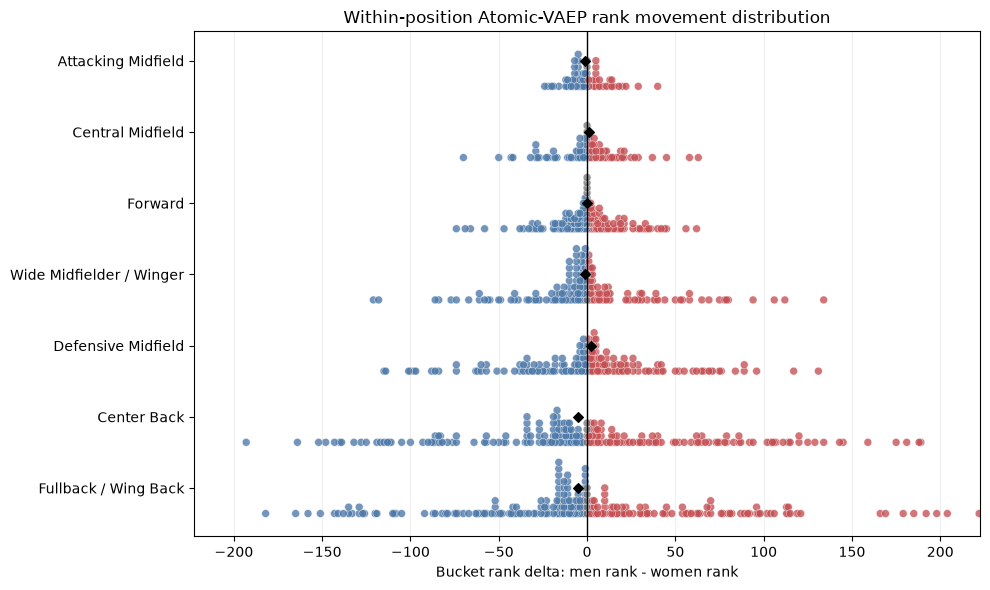

Note: position distributions are smoothed histograms, clipped to the 2%-98% player-delta range for readability. Each ridge is normalized to height 0.55, so shapes are comparable but player counts are shown in the summary table.


In [11]:
plot_position_summary = position_bucket_vaep_summary.sort_values("players", ascending=True)
position_bucket_order = plot_position_summary["position_bucket"].tolist()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, max(6, 0.45 * len(position_bucket_order) + 2)),
    gridspec_kw={"width_ratios": [0.9, 1.35]},
)

axes[0].barh(
    plot_position_summary["position_bucket"],
    plot_position_summary["spearman_men_vs_women_vaep"],
    color="#4C78A8",
)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel("Spearman: men-trained Atomic-VAEP vs women-trained Atomic-VAEP")
axes[0].set_title("Within-position ranking agreement")
for y_index, row in enumerate(plot_position_summary.itertuples(index=False)):
    label = "n=" + str(row.players)
    if pd.notna(row.spearman_men_vs_women_vaep):
        label = f"{row.spearman_men_vs_women_vaep:.2f} | " + label
    axes[0].text(
        0.02 if pd.isna(row.spearman_men_vs_women_vaep) else min(row.spearman_men_vs_women_vaep + 0.02, 0.98),
        y_index,
        label,
        va="center",
    )

POSITION_DISTRIBUTION_BINS = 140
POSITION_DISTRIBUTION_QUANTILES = (0.02, 0.98)
POSITION_SMOOTHING_WINDOW = 5
POSITION_RIDGE_HEIGHT = 0.55
POSITION_ROW_SPACING = 1.0

position_distribution_rows = player_vaep_by_position[
    player_vaep_by_position["position_bucket"].isin(position_bucket_order)
].copy()

x_min, x_max = position_distribution_rows["vaep_delta"].quantile(POSITION_DISTRIBUTION_QUANTILES)
if np.isclose(x_min, x_max):
    x_min -= 0.001
    x_max += 0.001

x_padding = 0.08 * (x_max - x_min)
x_min -= x_padding
x_max += x_padding

bin_edges = np.linspace(x_min, x_max, POSITION_DISTRIBUTION_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
smoothing_kernel = np.ones(POSITION_SMOOTHING_WINDOW) / POSITION_SMOOTHING_WINDOW

cmap = plt.colormaps["coolwarm"]
color_norm = plt.Normalize(
    plot_position_summary["mean_vaep_delta"].min(),
    plot_position_summary["mean_vaep_delta"].max(),
)
y_positions = np.arange(len(position_bucket_order)) * POSITION_ROW_SPACING

for y_position, position_bucket in zip(y_positions, position_bucket_order):
    values = position_distribution_rows.loc[
        position_distribution_rows["position_bucket"] == position_bucket,
        "vaep_delta",
    ].dropna().to_numpy()

    histogram, _ = np.histogram(values, bins=bin_edges, density=True)
    smoothed_density = np.convolve(histogram, smoothing_kernel, mode="same")
    if smoothed_density.max() > 0:
        smoothed_density = smoothed_density / smoothed_density.max() * POSITION_RIDGE_HEIGHT

    summary_row = plot_position_summary[plot_position_summary["position_bucket"] == position_bucket].iloc[0]
    ridge_color = cmap(color_norm(summary_row["mean_vaep_delta"]))

    axes[1].fill_between(
        bin_centers,
        y_position,
        y_position + smoothed_density,
        color=ridge_color,
        alpha=0.72,
        linewidth=0,
    )
    axes[1].plot(
        bin_centers,
        y_position + smoothed_density,
        color="black",
        linewidth=0.55,
        alpha=0.75,
    )
    axes[1].hlines(y_position, x_min, x_max, color="gray", linewidth=0.35, alpha=0.35)

    mean_delta = values.mean()
    if x_min <= mean_delta <= x_max:
        mean_height = np.interp(mean_delta, bin_centers, smoothed_density)
        axes[1].scatter(mean_delta, y_position + mean_height, color="black", s=16, zorder=4)

axes[1].axvline(0, color="black", linewidth=1.0, alpha=0.8)
axes[1].set_yticks(y_positions)
axes[1].set_yticklabels(position_bucket_order)
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_positions[0] - 0.25, y_positions[-1] + POSITION_RIDGE_HEIGHT + 0.25)
axes[1].set_xlabel("Player Atomic-VAEP delta: men model - women model")
axes[1].set_title("Distribution of Atomic-VAEP score shift by position bucket")
axes[1].grid(axis="x", alpha=0.18)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

ordered_buckets = position_bucket_vaep_summary.sort_values("players", ascending=False)["position_bucket"].tolist()
rank_distribution_rows = player_vaep_by_position.dropna(subset=["bucket_rank_delta"]).copy()
RANK_STACK_HEIGHT = 0.72
RANK_STACK_POINT_STEP = 0.09
RANK_STACK_BOTTOM = -RANK_STACK_HEIGHT / 2

fig, axis = plt.subplots(figsize=(10, max(6, 0.55 * len(ordered_buckets) + 2)))
for y_index, position_bucket in enumerate(ordered_buckets):
    bucket_rank_values = rank_distribution_rows.loc[
        rank_distribution_rows["position_bucket"].eq(position_bucket),
        "bucket_rank_delta",
    ].to_numpy()
    if len(bucket_rank_values) == 0:
        continue

    y_offsets = np.zeros_like(bucket_rank_values, dtype=float)
    unique_rank_values, rank_group_ids = np.unique(bucket_rank_values, return_inverse=True)
    max_stack_size = max(np.bincount(rank_group_ids))
    stack_step = min(
        RANK_STACK_POINT_STEP,
        RANK_STACK_HEIGHT / max(max_stack_size - 1, 1),
    )
    for rank_group_id in range(len(unique_rank_values)):
        matching_points = np.flatnonzero(rank_group_ids == rank_group_id)
        y_offsets[matching_points] = RANK_STACK_BOTTOM + np.arange(len(matching_points)) * stack_step

    rank_colors = np.where(
        bucket_rank_values > 0,
        "#C44E52",
        np.where(bucket_rank_values < 0, "#4C78A8", "#777777"),
    )
    axis.scatter(
        bucket_rank_values,
        y_index + y_offsets,
        color=rank_colors,
        alpha=0.78,
        s=32,
        edgecolors="white",
        linewidths=0.35,
    )
    axis.scatter(
        np.median(bucket_rank_values),
        y_index,
        color="black",
        marker="D",
        s=24,
        zorder=4,
    )

rank_limit = rank_distribution_rows["bucket_rank_delta"].abs().max()
if pd.isna(rank_limit) or rank_limit == 0:
    rank_limit = 1
axis.axvline(0, color="black", linewidth=1)
axis.set_xlim(-rank_limit - 0.5, rank_limit + 0.5)
axis.set_yticks(np.arange(len(ordered_buckets)))
axis.set_yticklabels(ordered_buckets)
axis.set_xlabel("Bucket rank delta: men rank - women rank")
axis.set_title("Within-position Atomic-VAEP rank movement distribution")
axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

print(
    "Note: position distributions are smoothed histograms, clipped to the "
    f"{POSITION_DISTRIBUTION_QUANTILES[0]:.0%}-{POSITION_DISTRIBUTION_QUANTILES[1]:.0%} player-delta range for readability. "
    f"Each ridge is normalized to height {POSITION_RIDGE_HEIGHT}, so shapes are comparable but player counts are shown in the summary table."
)

## 11. Action-type mechanism：哪些动作被男足模型和女足模型估值不同？

Atomic-VAEP 的优势是能看不同 action type 的差异。这里先按 action type 汇总 action-level Atomic-VAEP delta，然后不只看 mean，而是把每类动作的 delta distribution 画出来。

图里的横轴是 `vaep_delta = men_downsampled_vaep - women_vaep`。正值表示男足模型给该类女足 test atomic actions 的 Atomic-VAEP 更高；负值表示女足模型更高。

2D ridgeline 图的读法：每一行是一种 action type 的 delta 分布；隆起越高，说明该 delta 附近的 atomic actions 越多。每一行的颜色表示该 action type 的 mean delta：偏蓝表示女足模型平均给分更高，偏红表示男足模型平均给分更高。黑点标出该类动作的 mean delta。

Atomic action types with at least 500 test actions:


,type_name,actions,aggregate_vaep_delta,mean_vaep_delta,median_vaep_delta,delta_std,mean_men_vaep,mean_women_vaep
7,goal,676,-9.718658,-0.014377,0.013488,0.324912,0.536203,0.550580
2,corner,2178,-16.034371,-0.007362,-0.002883,0.118615,-0.001307,0.006055
0,bad_touch,8053,-35.623024,-0.004424,-0.000012,0.086296,-0.010623,-0.006200
3,cross,5023,-10.154236,-0.002022,-0.002674,0.039179,0.011191,0.013212
1,clearance,11250,-21.431325,-0.001905,0.000051,0.137729,0.000682,0.002587
11,out,10398,-19.244503,-0.001851,0.000062,0.089238,-0.025098,-0.023247
18,tackle,9424,-14.431181,-0.001531,0.000258,0.088199,-0.001101,0.000430
9,interception,42120,-49.596626,-0.001178,0.000221,0.072114,0.002543,0.003720
20,throw_in,12037,-13.038218,-0.001083,0.000293,0.048563,-0.000517,0.000566
19,take_on,7333,-3.509879,-0.000479,0.000007,0.028171,-0.001722,-0.001243


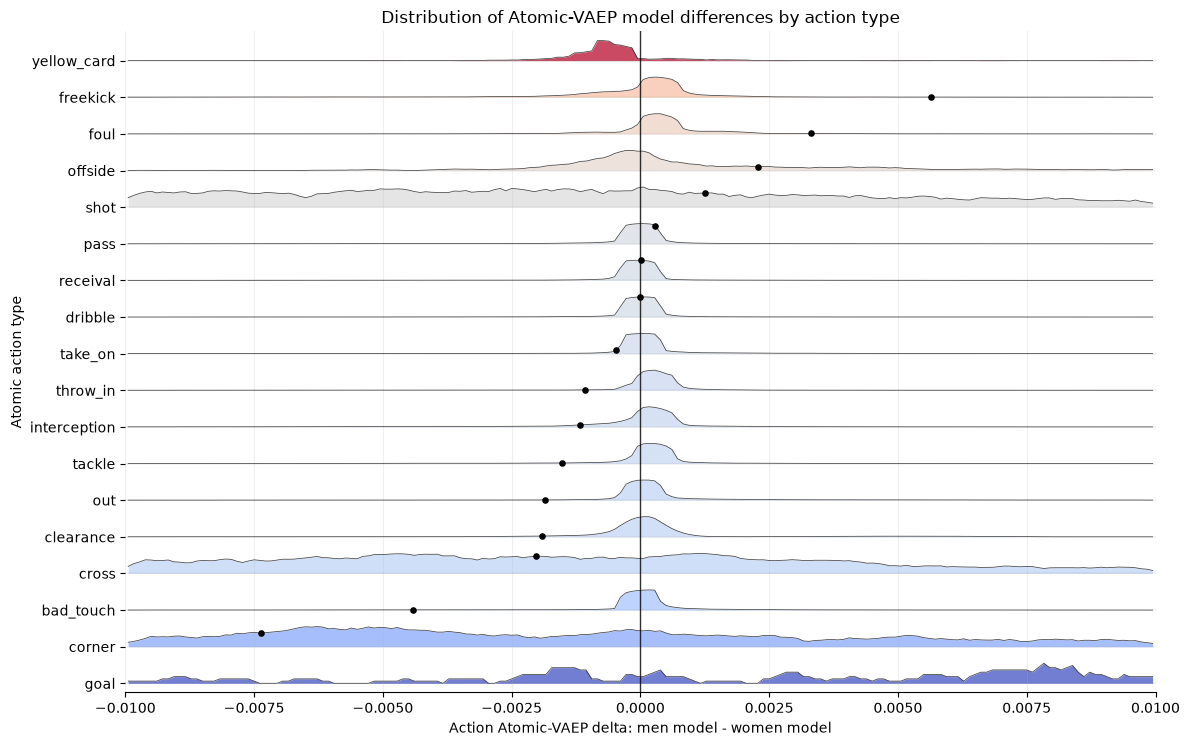

Note: distributions are smoothed histograms shown within [-0.01, +0.01] for readability. Each ridge is normalized to height 0.55, so shapes are comparable but absolute frequencies are shown in the table.


In [12]:
non_goalkeeper_predictions = vaep_predictions[~vaep_predictions["player_id_key"].map(is_goalkeeper_key)].copy()

action_type_vaep_summary = (
    non_goalkeeper_predictions
    .groupby("type_name")
    .agg(
        actions=("vaep_delta", "size"),
        aggregate_vaep_delta=("vaep_delta", "sum"),
        mean_vaep_delta=("vaep_delta", "mean"),
        median_vaep_delta=("vaep_delta", "median"),
        delta_std=("vaep_delta", "std"),
        mean_men_vaep=("men_downsampled_vaep", "mean"),
        mean_women_vaep=("women_vaep", "mean"),
    )
    .reset_index()
)

action_type_vaep_summary = action_type_vaep_summary[
    action_type_vaep_summary["actions"] >= MIN_ACTIONS_PER_ACTION_TYPE
].sort_values("mean_vaep_delta")

print(f"Atomic action types with at least {MIN_ACTIONS_PER_ACTION_TYPE:,} test actions:")
display(action_type_vaep_summary.round(6))

selected_action_types = action_type_vaep_summary["type_name"].tolist()
distribution_rows = non_goalkeeper_predictions[
    non_goalkeeper_predictions["type_name"].isin(selected_action_types)
].copy()

DISTRIBUTION_BINS = 180
SMOOTHING_WINDOW = 7
RIDGE_HEIGHT = 0.55
ROW_SPACING = 1.0
PLOT_DELTA_LIMIT = 0.01

x_min, x_max = -PLOT_DELTA_LIMIT, PLOT_DELTA_LIMIT

bin_edges = np.linspace(x_min, x_max, DISTRIBUTION_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
smoothing_kernel = np.ones(SMOOTHING_WINDOW) / SMOOTHING_WINDOW

fig_height = max(6, 0.32 * len(selected_action_types) + 1.8)
fig, axis = plt.subplots(figsize=(12, fig_height))

cmap = plt.colormaps["coolwarm"]
color_norm = plt.Normalize(
    action_type_vaep_summary["mean_vaep_delta"].min(),
    action_type_vaep_summary["mean_vaep_delta"].max(),
)

y_positions = np.arange(len(selected_action_types)) * ROW_SPACING

for y_position, action_type in zip(y_positions, selected_action_types):
    values = distribution_rows.loc[
        distribution_rows["type_name"] == action_type,
        "vaep_delta",
    ].dropna().to_numpy()

    histogram, _ = np.histogram(values, bins=bin_edges, density=True)
    smoothed_density = np.convolve(histogram, smoothing_kernel, mode="same")
    if smoothed_density.max() > 0:
        smoothed_density = smoothed_density / smoothed_density.max() * RIDGE_HEIGHT

    summary_row = action_type_vaep_summary[action_type_vaep_summary["type_name"] == action_type].iloc[0]
    ridge_color = cmap(color_norm(summary_row["mean_vaep_delta"]))

    axis.fill_between(
        bin_centers,
        y_position,
        y_position + smoothed_density,
        color=ridge_color,
        alpha=0.72,
        linewidth=0,
    )
    axis.plot(
        bin_centers,
        y_position + smoothed_density,
        color="black",
        linewidth=0.55,
        alpha=0.75,
    )
    axis.hlines(y_position, x_min, x_max, color="gray", linewidth=0.35, alpha=0.35)

    mean_delta = values.mean()
    if x_min <= mean_delta <= x_max:
        mean_height = np.interp(mean_delta, bin_centers, smoothed_density)
        axis.scatter(mean_delta, y_position + mean_height, color="black", s=14, zorder=4)

axis.axvline(0, color="black", linewidth=1.0, alpha=0.8)
axis.set_yticks(y_positions)
axis.set_yticklabels(selected_action_types)
axis.set_xlim(x_min, x_max)
axis.set_ylim(y_positions[0] - 0.25, y_positions[-1] + RIDGE_HEIGHT + 0.25)
axis.set_xlabel("Action Atomic-VAEP delta: men model - women model")
axis.set_ylabel("Atomic action type")
axis.set_title("Distribution of Atomic-VAEP model differences by action type")
axis.grid(axis="x", alpha=0.18)
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)
axis.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

print(
    "Note: distributions are smoothed histograms shown within "
    f"[-{PLOT_DELTA_LIMIT:.2f}, +{PLOT_DELTA_LIMIT:.2f}] for readability. "
    f"Each ridge is normalized to height {RIDGE_HEIGHT}, so shapes are comparable but absolute frequencies are shown in the table."
)

## 12. Event spatial maps：shot / pass / receival / dribble / cross 的空间差异

这一节把上一节的 action-type 差异放回 2D 球场上看。

每张图只看一种 atomic event type，并把女足 test atomic actions 按 `x, y` 落到 12x16 grid 里。颜色表示该 grid 内：

`mean_vaep_delta = mean(men_downsampled_vaep - women_vaep)`

- 红色：男足训练模型平均给这个区域 / 这个 event type 更高的 Atomic-VAEP。
- 蓝色：女足训练模型平均给这个区域 / 这个 event type 更高的 Atomic-VAEP。
- 空白：该 grid 的样本数低于 `MIN_SPATIAL_GRID_ACTIONS`，避免低样本格子误导。

注意：这里使用 atomic action 的 `x, y`。对 `pass` / `cross` / `dribble` 来说是动作起点；对 `receival` 来说是接球点；对 `shot` 来说是射门点。

Spatial event-grid summary, filtered to common event types:


,type_name,grid_row,grid_col,actions,aggregate_vaep_delta,mean_vaep_delta,median_vaep_delta,mean_men_vaep,mean_women_vaep
17,cross,3,15,339,0.164429,0.000485,0.007358,0.011444,0.010959
21,cross,8,15,307,0.071080,0.000232,0.007032,0.008141,0.007910
8,cross,1,14,292,-0.372952,-0.001277,-0.002994,0.013564,0.014841
14,cross,2,15,247,1.418661,0.005744,0.005450,0.017663,0.011920
9,cross,1,15,240,1.624141,0.006767,0.004525,0.011959,0.005191
30,cross,10,14,233,-0.443678,-0.001904,-0.003474,0.015176,0.017081
25,cross,9,14,227,-0.163211,-0.000719,-0.002051,0.014925,0.015644
7,cross,1,13,211,-1.935042,-0.009171,-0.010346,0.011529,0.020700
13,cross,2,14,209,0.110220,0.000527,0.000775,0.016524,0.015997
31,cross,10,15,185,0.744432,0.004024,0.002636,0.009424,0.005400


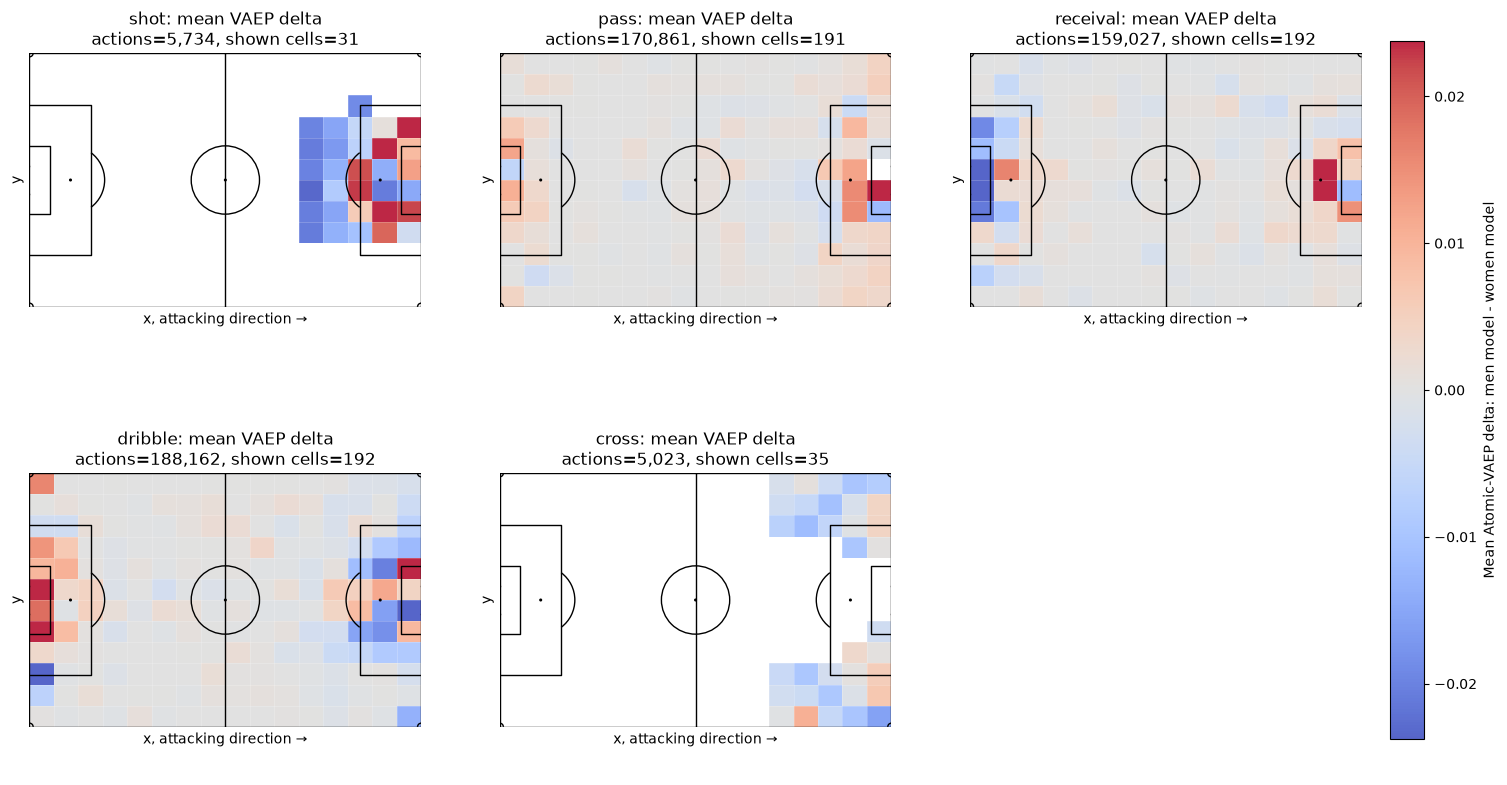

Note: all panels use the same symmetric color scale, clipped at the 98th percentile of absolute grid mean deltas. Cells with fewer than 20 actions are hidden.


In [13]:
EVENT_TYPES_FOR_PITCH = ["shot", "pass", "receival", "dribble", "cross"]


def add_spatial_grid_columns(actions, rows=SPATIAL_GRID_ROWS, cols=SPATIAL_GRID_COLS):
    """Add integer grid row/column indices from atomic action x/y coordinates."""
    actions = actions.copy()
    actions["x"] = pd.to_numeric(actions["x"], errors="coerce")
    actions["y"] = pd.to_numeric(actions["y"], errors="coerce")
    actions = actions.dropna(subset=["x", "y", "vaep_delta"])
    actions = actions[
        actions["x"].between(0, PITCH_LENGTH)
        & actions["y"].between(0, PITCH_WIDTH)
    ].copy()

    actions["grid_col"] = np.floor(actions["x"] / PITCH_LENGTH * cols).astype(int).clip(0, cols - 1)
    actions["grid_row"] = np.floor(actions["y"] / PITCH_WIDTH * rows).astype(int).clip(0, rows - 1)
    return actions


spatial_event_rows = non_goalkeeper_predictions[
    non_goalkeeper_predictions["type_name"].isin(EVENT_TYPES_FOR_PITCH)
].copy()
spatial_event_rows = add_spatial_grid_columns(spatial_event_rows)

spatial_event_summary = (
    spatial_event_rows
    .groupby(["type_name", "grid_row", "grid_col"])
    .agg(
        actions=("vaep_delta", "size"),
        aggregate_vaep_delta=("vaep_delta", "sum"),
        mean_vaep_delta=("vaep_delta", "mean"),
        median_vaep_delta=("vaep_delta", "median"),
        mean_men_vaep=("men_downsampled_vaep", "mean"),
        mean_women_vaep=("women_vaep", "mean"),
    )
    .reset_index()
)

print("Spatial event-grid summary, filtered to common event types:")
display(
    spatial_event_summary.sort_values(["type_name", "actions"], ascending=[True, False])
    .head(30)
    .round(6)
)


def event_grid_matrix(event_summary, metric, rows=SPATIAL_GRID_ROWS, cols=SPATIAL_GRID_COLS):
    """Convert one event-type grid summary metric into a rows x cols matrix."""
    matrix = np.full((rows, cols), np.nan)
    for row in event_summary.itertuples(index=False):
        matrix[int(row.grid_row), int(row.grid_col)] = getattr(row, metric)
    return matrix


def plot_event_delta_pitch(axis, event_type, spatial_summary, vmin, vmax):
    """Plot mean VAEP delta for one atomic event type over a 105x68 pitch."""
    pitch = Pitch(
        pitch_type="custom",
        pitch_length=PITCH_LENGTH,
        pitch_width=PITCH_WIDTH,
        pitch_color="white",
        line_color="black",
        linewidth=1.0,
        line_zorder=3,
        goal_type="box",
        corner_arcs=True,
    )
    pitch.draw(ax=axis)

    event_summary = spatial_summary[spatial_summary["type_name"].eq(event_type)].copy()
    total_actions = int(event_summary["actions"].sum()) if len(event_summary) else 0
    shown_cells = int((event_summary["actions"] >= MIN_SPATIAL_GRID_ACTIONS).sum()) if len(event_summary) else 0

    if event_summary.empty:
        axis.text(
            PITCH_LENGTH / 2,
            PITCH_WIDTH / 2,
            f"No {event_type} actions",
            ha="center",
            va="center",
            fontsize=12,
        )
        axis.set_title(f"{event_type}: no data")
        return None

    event_summary.loc[event_summary["actions"] < MIN_SPATIAL_GRID_ACTIONS, "mean_vaep_delta"] = np.nan
    matrix = np.ma.masked_invalid(event_grid_matrix(event_summary, "mean_vaep_delta"))
    colormap = plt.get_cmap("coolwarm").copy()
    colormap.set_bad(color="white", alpha=0.0)

    image = axis.imshow(
        matrix,
        origin="lower",
        extent=[0, PITCH_LENGTH, 0, PITCH_WIDTH],
        aspect="equal",
        cmap=colormap,
        vmin=vmin,
        vmax=vmax,
        interpolation="none",
        alpha=0.86,
        zorder=1,
    )

    for x_value in np.linspace(0, PITCH_LENGTH, SPATIAL_GRID_COLS + 1):
        axis.plot([x_value, x_value], [0, PITCH_WIDTH], color="white", alpha=0.35, linewidth=0.4, zorder=2)
    for y_value in np.linspace(0, PITCH_WIDTH, SPATIAL_GRID_ROWS + 1):
        axis.plot([0, PITCH_LENGTH], [y_value, y_value], color="white", alpha=0.35, linewidth=0.4, zorder=2)

    axis.set_title(
        f"{event_type}: mean VAEP delta\n"
        f"actions={total_actions:,}, shown cells={shown_cells}"
    )
    axis.set_xlim(0, PITCH_LENGTH)
    axis.set_ylim(0, PITCH_WIDTH)
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x, attacking direction →")
    axis.set_ylabel("y")
    return image


plot_spatial_summary = spatial_event_summary[
    spatial_event_summary["type_name"].isin(EVENT_TYPES_FOR_PITCH)
    & (spatial_event_summary["actions"] >= MIN_SPATIAL_GRID_ACTIONS)
].copy()

if plot_spatial_summary.empty:
    raise ValueError(
        "No event/grid cells have enough actions to plot. "
        "Lower MIN_SPATIAL_GRID_ACTIONS or check EVENT_TYPES_FOR_PITCH."
    )

max_abs_delta = plot_spatial_summary["mean_vaep_delta"].abs().quantile(0.98)
if not np.isfinite(max_abs_delta) or max_abs_delta == 0:
    max_abs_delta = plot_spatial_summary["mean_vaep_delta"].abs().max()
if not np.isfinite(max_abs_delta) or max_abs_delta == 0:
    max_abs_delta = 0.001

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.ravel()
images = []
for axis, event_type in zip(axes_flat, EVENT_TYPES_FOR_PITCH):
    image = plot_event_delta_pitch(
        axis,
        event_type,
        spatial_event_summary,
        vmin=-max_abs_delta,
        vmax=max_abs_delta,
    )
    if image is not None:
        images.append(image)

for axis in axes_flat[len(EVENT_TYPES_FOR_PITCH):]:
    axis.axis("off")

if images:
    fig.colorbar(
        images[0],
        ax=axes_flat.tolist(),
        fraction=0.025,
        pad=0.02,
        label="Mean Atomic-VAEP delta: men model - women model",
    )

plt.show()

print(
    "Note: all panels use the same symmetric color scale, clipped at the 98th percentile of absolute grid mean deltas. "
    f"Cells with fewer than {MIN_SPATIAL_GRID_ACTIONS} actions are hidden."
)


## 13. Read-out

这个 notebook 最后应该回答：

1. 男足训练的 Atomic-VAEP 模型和女足训练的 Atomic-VAEP 模型，在同一批女足 test atomic actions 上给出的球员排名有多一致？
2. 差异是否集中在某些 position bucket？
3. 差异是否集中在某些 atomic action type，例如 receival、interception、goal 或 out？
4. shot / pass / receival / dribble / cross 的差异在空间上是否集中在某些区域？

如果 Atomic-VAEP 比标准 VAEP 显示更低 Spearman 或更明显的位置/action-type 差异，说明更细粒度的 action-value representation 捕捉到了普通 SPADL VAEP 看不到的迁移差异。